In [1]:
import os

for i in  range(10):
    dir_text = !dir
    if any([".venv" in text for text in dir_text]):
        print(".venv encontrado")
        break
    else:
        print(f'{i} - os.chdir("..")')
        os.chdir("..")


%load_ext autoreload
%autoreload 2

0 - os.chdir("..")
1 - os.chdir("..")
.venv encontrado


A simple way to detect and change the color of an object in an image to transform the image from an RGB to HSV color space and then use a range of hues to detect the object, this can be easily done using OpenCV-Python.

We need to specify a range of color values using which the object we are interested in will be identified and extracted. We can change the color of the object detected and even make the object detected transparent.

In [ ]:
import cv2
import numpy as np
import matplotlib.pylab as plt
from libs import utils

path = "data/images/image03.jpg"
img = cv2.imread(path)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

mask = cv2.inRange(hsv, lowerb=(0, 200, 25), upperb=(15, 255, 255))
imask = mask>0
brown = np.zeros_like(img)
brown[imask] = img[imask]

In [9]:
black = img.copy()
hsv[...,0:3] = hsv[...,0:3] / 3
black[imask] = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)[imask]
black = np.clip(black, 0, 255)

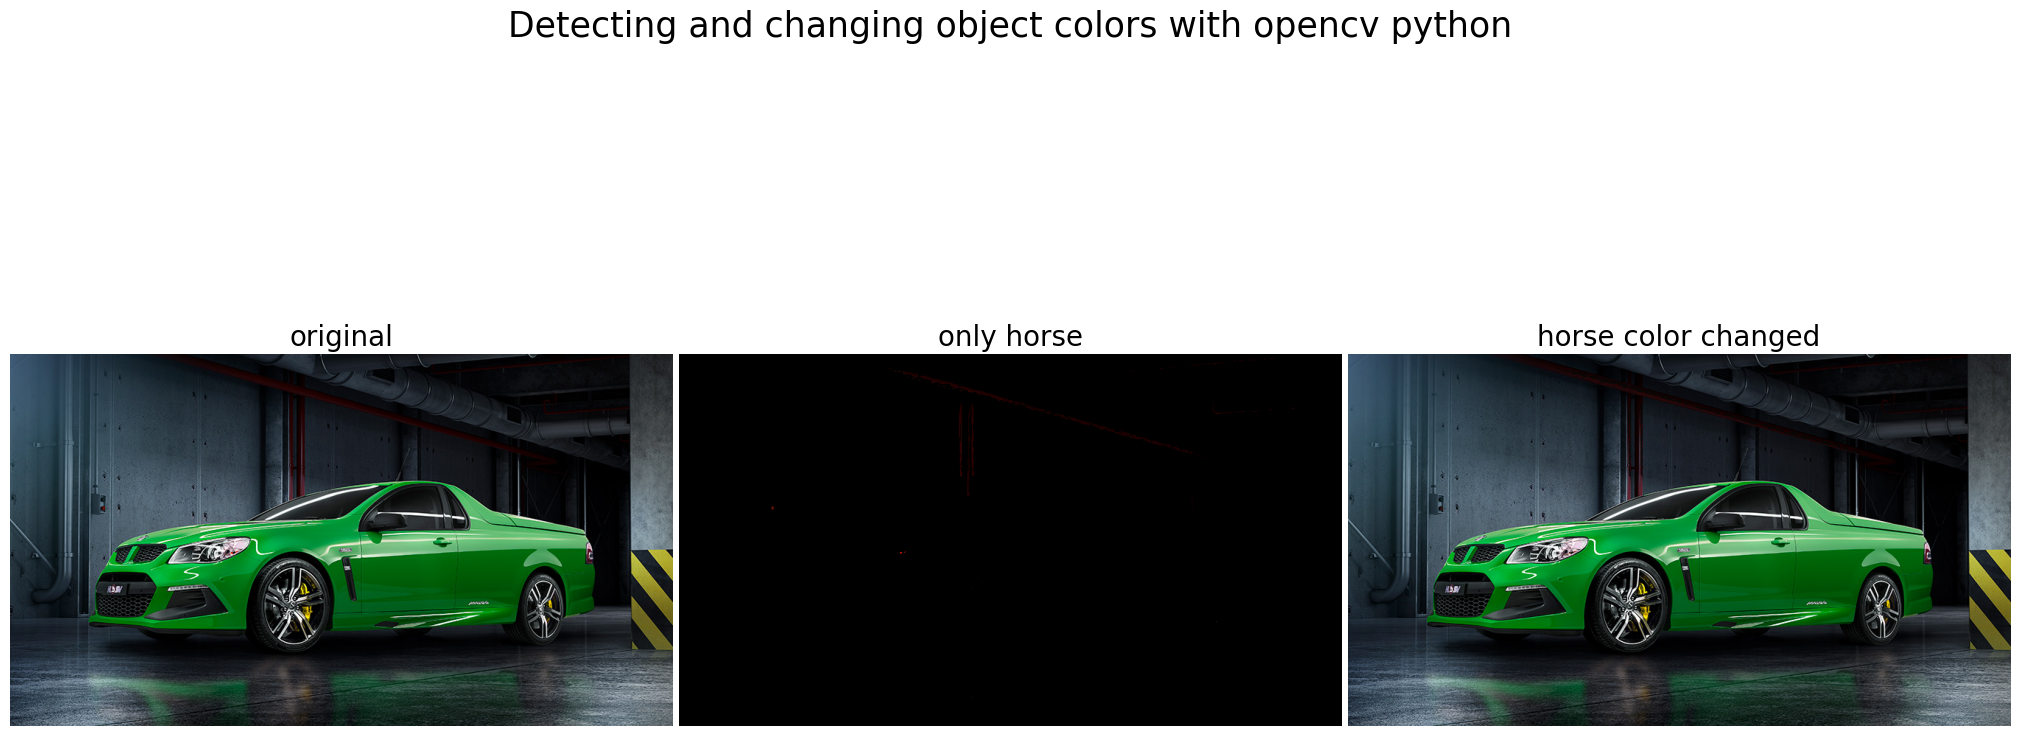

In [10]:
plt.figure(figsize=(20,10))
plt.subplots_adjust(0,0,1,0.9,0.01,0.075)
plt.subplot(131), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.axis('off'),
plt.title('original', size=20)
plt.subplot(132), plt.imshow(cv2.cvtColor(brown, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.title('only horse', size=20)
plt.subplot(133), plt.imshow(cv2.cvtColor(black, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.title('horse color changed', size=20)
plt.suptitle('Detecting and changing object colors with opencv python', size=25)
plt.show()

In [ ]:
import cv2
import numpy as np

# Caminho da imagem
path = "data/images/shapes.png"
img = cv2.imread(path)
img_display = img.copy()

# Função de clique
def selecionar_cor(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        # Pega a cor HSV do pixel clicado
        hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        cor_hsv = hsv_img[y, x]
        h, s, v = cor_hsv
        print(f"HSV selecionado: H={h}, S={s}, V={v}")

        # Define faixa de cor com tolerância
        tolerancia = 30
        lowerb = np.array([max(h - tolerancia, 0), max(s - 50, 0), max(v - 50, 0)])
        upperb = np.array([min(h + tolerancia, 179), min(s + 50, 255), min(v + 50, 255)])

        # Cria máscara
        mask = cv2.inRange(hsv_img, lowerb, upperb)
        imask = mask > 0

        # Cria imagem com objeto isolado
        objeto = np.zeros_like(img)
        objeto[imask] = img[imask]

        # Altera cor do objeto
        hsv_modificado = hsv_img.copy()
        hsv_modificado[..., 0:3] = hsv_modificado[..., 0:3] / 3
        alterado = img.copy()
        alterado[imask] = cv2.cvtColor(hsv_modificado, cv2.COLOR_HSV2BGR)[imask]

        # Exibe resultados
        cv2.imshow("Original", img)
        cv2.imshow("Objeto Detectado", objeto)
        cv2.imshow("Objeto com Cor Alterada", alterado)

# Janela interativa
cv2.namedWindow("Selecione um ponto")
cv2.setMouseCallback("Selecione um ponto", selecionar_cor)
cv2.imshow("Selecione um ponto", img_display)
cv2.waitKey(0)
cv2.destroyAllWindows()